In [1]:
#Library
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import random

In [2]:
# --- PHASE 1: FIXED HYPERPARAMETERS ---
BATCH_SIZE = 64
LEARNING_RATE = 0.001
EPOCHS = 15
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES = 10
IMG_SIZE = 32

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
print(f"Using Device: {DEVICE}")

Using Device: cpu


In [3]:
# --- PHASE 2: DATASET & PIPELINE ---
class FashionCSVDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        data = pd.read_csv(csv_file)
        self.labels = data.iloc[:, 0].values
        self.images = data.iloc[:, 1:].values.astype('uint8')
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = self.images[idx].reshape(28, 28)
        label = int(self.labels[idx])
        if self.transform:
            image = self.transform(image)
        return image, label

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load and Split
full_train_dataset = FashionCSVDataset('fashion-mnist_train.csv', transform=transform)
test_dataset = FashionCSVDataset('fashion-mnist_test.csv', transform=transform)

train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_data, val_data = random_split(full_train_dataset, [train_size, val_size])

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [4]:
# --- PHASE 3: MODEL ARCHITECTURE ---
class CustomCNN(nn.Module):
    def __init__(self, input_channels=1):
        super(CustomCNN, self).__init__()
        self.conv1 = nn.Conv2d(input_channels, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(2, 2)
        
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, NUM_CLASSES)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# --- PHASE 4: LOSS FUNCTIONS ---
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt)**self.gamma * ce_loss
        return focal_loss.mean()

loss_functions = {
    "CrossEntropy": nn.CrossEntropyLoss(),
    "MSE": nn.MSELoss(),
    "LabelSmoothing": nn.CrossEntropyLoss(label_smoothing=0.1),
    "FocalLoss": FocalLoss()
}

In [5]:
# --- PHASE 5: EXECUTION LOOP ---
results_history = {}
trained_models = {}

for name, criterion in loss_functions.items():
    print(f"\n--- Starting Experiment: {name} ---")
    model = CustomCNN().to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    
    history = {'train_loss': [], 'val_acc': []}
    
    for epoch in range(EPOCHS):
        model.train()
        epoch_loss = 0
        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            
            if name == "MSE":
                labels_oh = F.one_hot(labels, NUM_CLASSES).float()
                loss = criterion(F.softmax(outputs, dim=1), labels_oh)
            else:
                loss = criterion(outputs, labels)
                
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            
        # Validation
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs = model(images)
                _, pred = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (pred == labels).sum().item()
        
        acc = 100 * correct / total
        avg_loss = epoch_loss / len(train_loader)
        history['train_loss'].append(avg_loss)
        history['val_acc'].append(acc)
        print(f"Epoch [{epoch+1}/{EPOCHS}] Loss: {avg_loss:.4f} Acc: {acc:.2f}%")
    
    results_history[name] = history
    trained_models[name] = model


--- Starting Experiment: CrossEntropy ---
Epoch [1/15] Loss: 0.4762 Acc: 88.28%
Epoch [2/15] Loss: 0.3278 Acc: 89.70%
Epoch [3/15] Loss: 0.2825 Acc: 90.51%
Epoch [4/15] Loss: 0.2519 Acc: 90.12%
Epoch [5/15] Loss: 0.2297 Acc: 91.24%
Epoch [6/15] Loss: 0.2071 Acc: 91.68%
Epoch [7/15] Loss: 0.1938 Acc: 91.42%
Epoch [8/15] Loss: 0.1753 Acc: 92.16%
Epoch [9/15] Loss: 0.1574 Acc: 92.28%
Epoch [10/15] Loss: 0.1421 Acc: 92.38%
Epoch [11/15] Loss: 0.1298 Acc: 92.37%
Epoch [12/15] Loss: 0.1198 Acc: 92.47%
Epoch [13/15] Loss: 0.1081 Acc: 92.35%
Epoch [14/15] Loss: 0.0981 Acc: 92.40%
Epoch [15/15] Loss: 0.0883 Acc: 92.41%

--- Starting Experiment: MSE ---
Epoch [1/15] Loss: 0.0262 Acc: 88.17%
Epoch [2/15] Loss: 0.0180 Acc: 89.42%
Epoch [3/15] Loss: 0.0158 Acc: 89.53%
Epoch [4/15] Loss: 0.0143 Acc: 90.42%
Epoch [5/15] Loss: 0.0133 Acc: 91.55%
Epoch [6/15] Loss: 0.0122 Acc: 91.66%
Epoch [7/15] Loss: 0.0113 Acc: 91.53%
Epoch [8/15] Loss: 0.0108 Acc: 92.13%
Epoch [9/15] Loss: 0.0099 Acc: 92.31%
Epoch

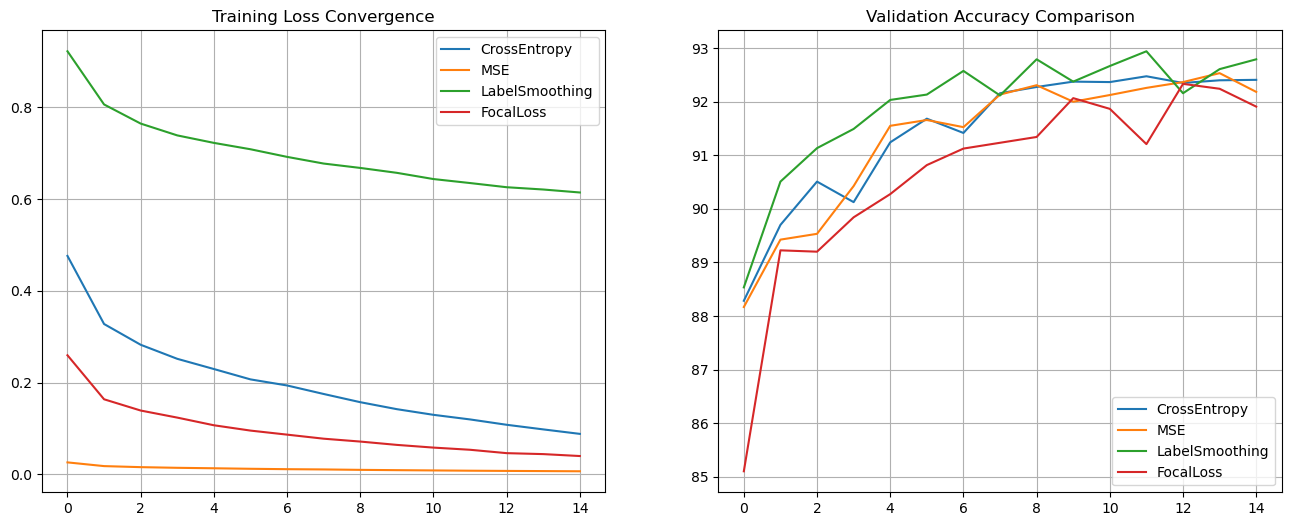


DETAILED PERFORMANCE REPORT FOR: CrossEntropy
              precision    recall  f1-score   support

     T-shirt    0.86341   0.88500   0.87407      1000
     Trouser    0.98709   0.99400   0.99053      1000
    Pullover    0.91341   0.86500   0.88855      1000
       Dress    0.91420   0.95900   0.93607      1000
        Coat    0.88213   0.91300   0.89730      1000
      Sandal    0.98993   0.98300   0.98645      1000
       Shirt    0.83205   0.75800   0.79330      1000
     Sneaker    0.96219   0.96700   0.96459      1000
         Bag    0.96887   0.99600   0.98225      1000
  Ankle boot    0.97500   0.97500   0.97500      1000

    accuracy                        0.92950     10000
   macro avg    0.92883   0.92950   0.92881     10000
weighted avg    0.92883   0.92950   0.92881     10000



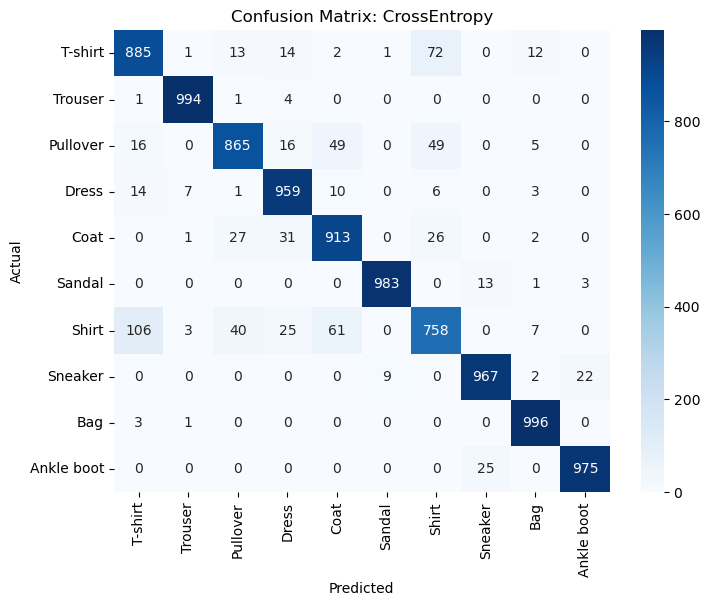


DETAILED PERFORMANCE REPORT FOR: MSE
              precision    recall  f1-score   support

     T-shirt    0.92563   0.80900   0.86339      1000
     Trouser    0.98611   0.99400   0.99004      1000
    Pullover    0.92971   0.87300   0.90046      1000
       Dress    0.93675   0.93300   0.93487      1000
        Coat    0.88738   0.91400   0.90049      1000
      Sandal    0.99286   0.97400   0.98334      1000
       Shirt    0.74276   0.84600   0.79102      1000
     Sneaker    0.94503   0.98000   0.96220      1000
         Bag    0.98026   0.99300   0.98659      1000
  Ankle boot    0.97864   0.96200   0.97025      1000

    accuracy                        0.92780     10000
   macro avg    0.93051   0.92780   0.92827     10000
weighted avg    0.93051   0.92780   0.92827     10000



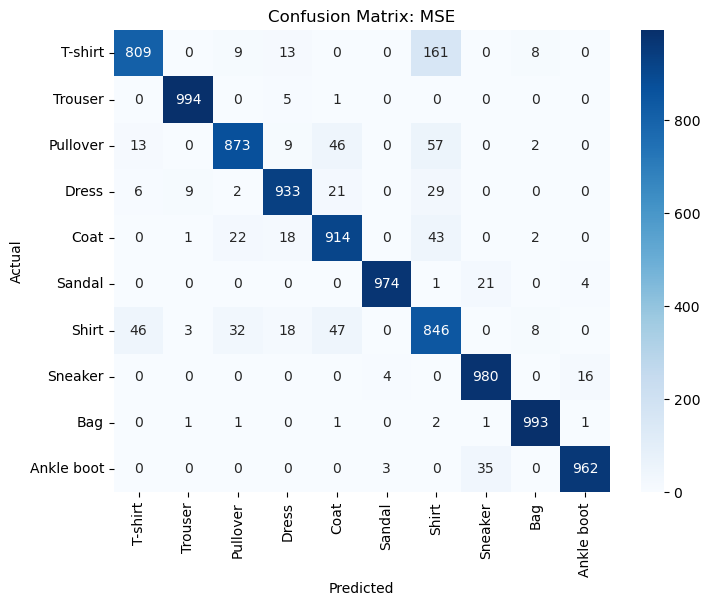


DETAILED PERFORMANCE REPORT FOR: LabelSmoothing
              precision    recall  f1-score   support

     T-shirt    0.88501   0.86200   0.87335      1000
     Trouser    0.99399   0.99300   0.99350      1000
    Pullover    0.88998   0.90600   0.89792      1000
       Dress    0.93600   0.93600   0.93600      1000
        Coat    0.88436   0.93300   0.90803      1000
      Sandal    0.99189   0.97800   0.98489      1000
       Shirt    0.81714   0.78200   0.79918      1000
     Sneaker    0.95846   0.96900   0.96370      1000
         Bag    0.99197   0.98800   0.98998      1000
  Ankle boot    0.97112   0.97500   0.97305      1000

    accuracy                        0.93220     10000
   macro avg    0.93199   0.93220   0.93196     10000
weighted avg    0.93199   0.93220   0.93196     10000



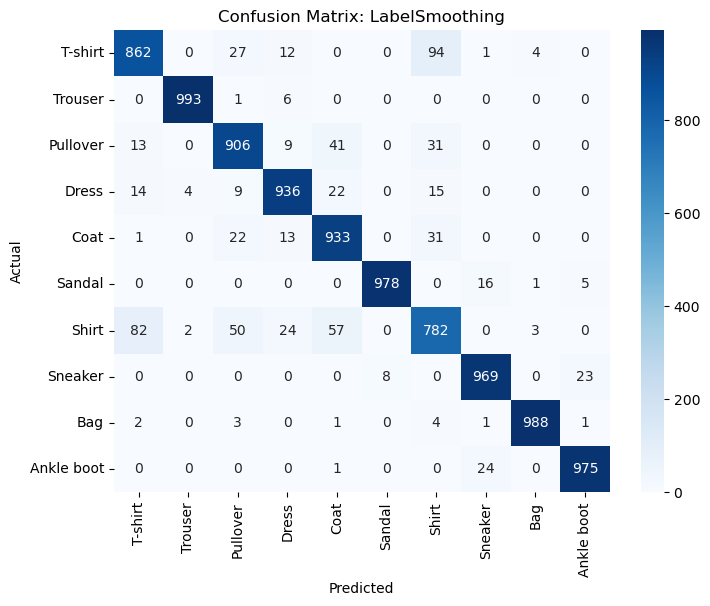


DETAILED PERFORMANCE REPORT FOR: FocalLoss
              precision    recall  f1-score   support

     T-shirt    0.86804   0.88800   0.87790      1000
     Trouser    0.98810   0.99600   0.99203      1000
    Pullover    0.91374   0.85800   0.88499      1000
       Dress    0.95124   0.91700   0.93381      1000
        Coat    0.86673   0.91700   0.89116      1000
      Sandal    0.99389   0.97600   0.98486      1000
       Shirt    0.79266   0.79900   0.79582      1000
     Sneaker    0.92409   0.98600   0.95404      1000
         Bag    0.99300   0.99300   0.99300      1000
  Ankle boot    0.98633   0.93800   0.96156      1000

    accuracy                        0.92680     10000
   macro avg    0.92778   0.92680   0.92692     10000
weighted avg    0.92778   0.92680   0.92692     10000



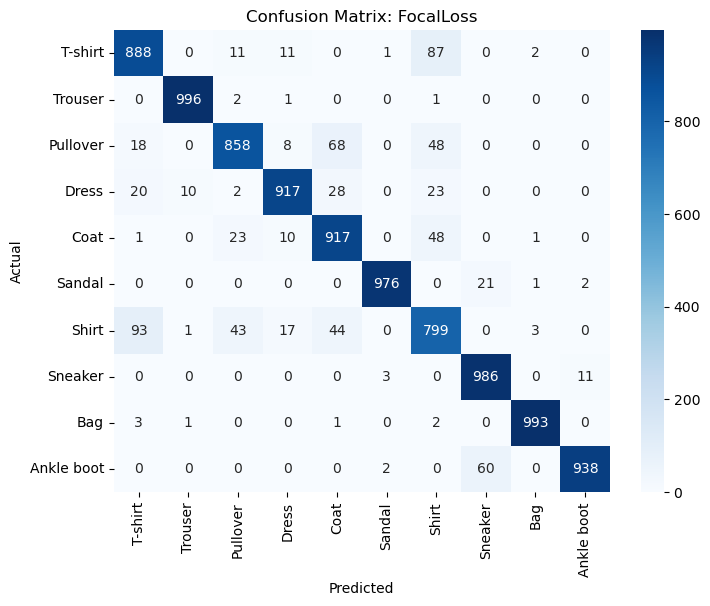

In [6]:
# --- PHASE 6: FINAL ANALYSIS & VISUALIZATION (HIGH PRECISION) ---
def finalize_report(results, models, test_loader):
    # 1. Plot Curves
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    for n, h in results.items():
        ax1.plot(h['train_loss'], label=n)
        ax2.plot(h['val_acc'], label=n)
    ax1.set_title('Training Loss Convergence'); ax1.legend(); ax1.grid(True)
    ax2.set_title('Validation Accuracy Comparison'); ax2.legend(); ax2.grid(True)
    plt.show()

    # Class names for Fashion-MNIST
    classes = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat', 
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

    # 2. Detailed Metrics for Each with High Precision
    for n, m in models.items():
        m.eval()
        y_t, y_p = [], []
        with torch.no_grad():
            for img, lbl in test_loader:
                img, lbl = img.to(DEVICE), lbl.to(DEVICE)
                out = m(img)
                _, p = torch.max(out, 1)
                y_t.extend(lbl.cpu().numpy())
                y_p.extend(p.cpu().numpy())
        
        # Performance Report
        print(f"\n{'='*60}")
        print(f"DETAILED PERFORMANCE REPORT FOR: {n}")
        print(f"{'='*60}")
        
        
        print(classification_report(y_t, y_p, target_names=classes, digits=5))

        # 3. Optional: Plot Confusion Matrix for visual error analysis
        plt.figure(figsize=(8, 6))
        cm = confusion_matrix(y_t, y_p)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
        plt.title(f'Confusion Matrix: {n}')
        plt.ylabel('Actual')
        plt.xlabel('Predicted')
        plt.show()

# Run Final Report with 4-decimal precision
finalize_report(results_history, trained_models, test_loader)